In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("Walmart Data Analysis and Forcasting.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
print(df.shape)
df.info()

(6435, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [5]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst = True)

In [6]:
df = df.sort_values(by="Date")

In [7]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00.000000256,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


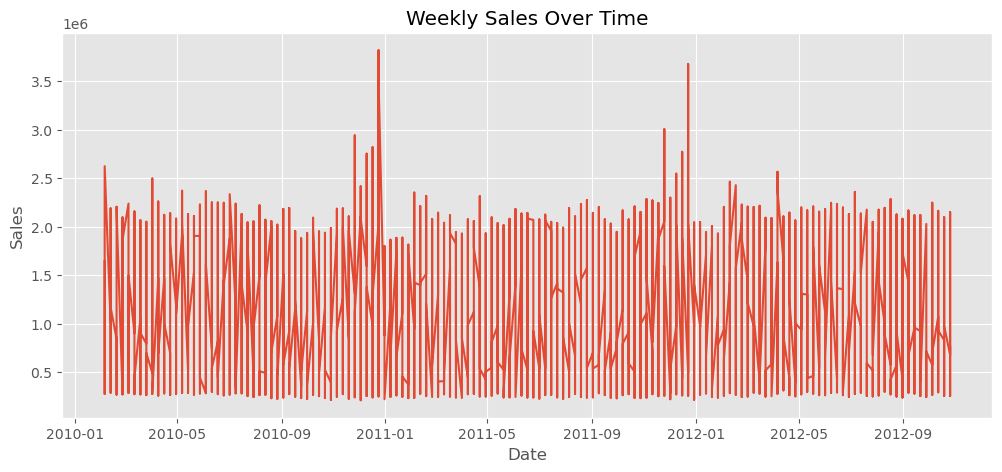

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Weekly_Sales"])

plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

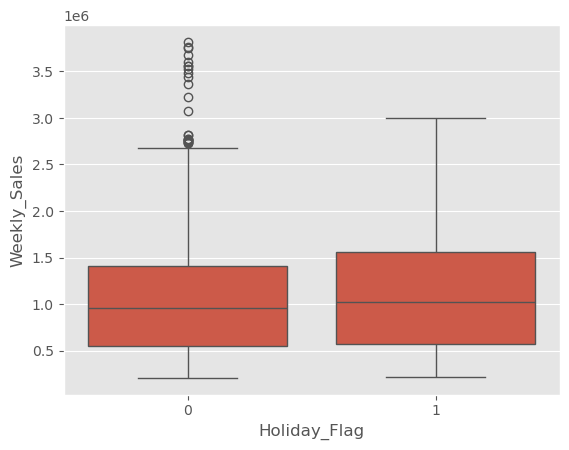

In [9]:
sns.boxplot(data=df, x="Holiday_Flag", y="Weekly_Sales")
plt.show()

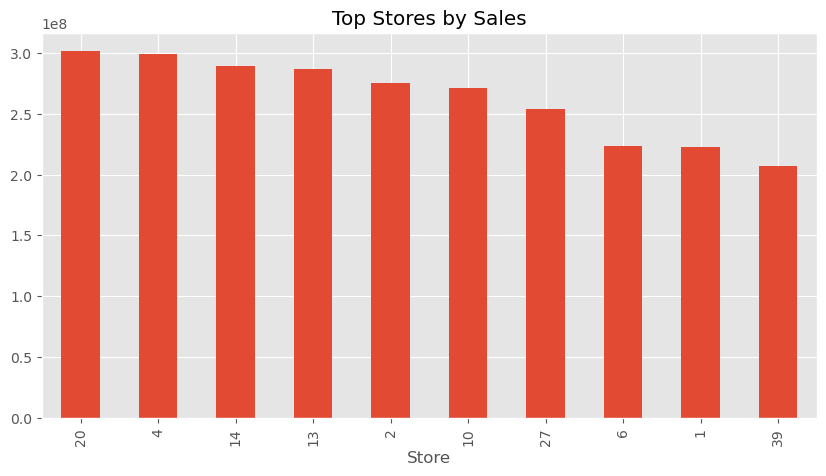

In [10]:
top_stores = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10)

top_stores.plot(kind="bar", figsize=(10,5))
plt.title("Top Stores by Sales")
plt.show()

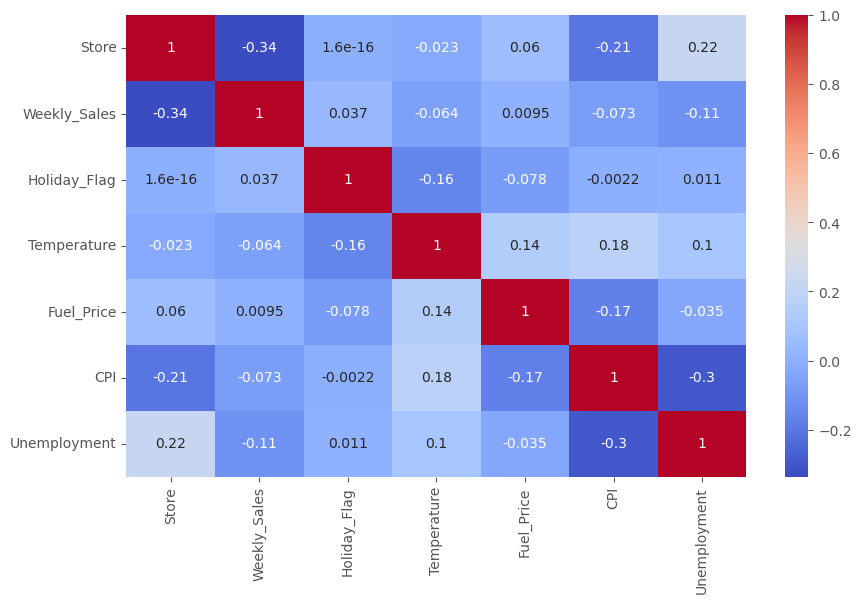

In [11]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [12]:
print(df["Weekly_Sales"].mean())
print(df["Weekly_Sales"].median())
print(df["Weekly_Sales"].mode()[0])

1046964.8775617717
960746.04
209986.25


In [13]:
print(df["Weekly_Sales"].var())
print(df["Weekly_Sales"].std())

318509684088.30084
564366.6220536974


In [14]:
print(df["Weekly_Sales"].skew())

0.6683617974864517


In [15]:
mean = df["Weekly_Sales"].mean()
std = df["Weekly_Sales"].std()
n = len(df)

ci = 1.96 * (std/np.sqrt(n))

print(mean-ci, mean+ci)

1033175.549106856 1060754.2060166874


In [16]:
from scipy.stats import ttest_ind

holiday = df[df["Holiday_Flag"] == 1]["Weekly_Sales"]
non_holiday = df[df["Holiday_Flag"] == 0]["Weekly_Sales"]

t, p = ttest_ind(holiday, non_holiday)

print(t, p)

2.9608919093259076 0.0030786992638185723


In [17]:
if p < 0.05:
    print("Holiday significantly affects sales")
else:
    print("No significant effect")

Holiday significantly affects sales


In [18]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day
df["Quarter"] = df["Date"].dt.quarter

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5,1
1287,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765,2010,2,5,5,1
5148,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554,2010,2,5,5,1
2288,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548,2010,2,5,5,1
4147,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324,2010,2,5,5,1


In [19]:
df["Lag_1"] = df["Weekly_Sales"].shift(1)
df["Lag_2"] = df["Weekly_Sales"].shift(2)
df["Lag_3"] = df["Weekly_Sales"].shift(3)

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day,Quarter,Lag_1,Lag_2,Lag_3
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5,1,NaN,NaN,NaN
1287,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765,2010,2,5,5,1,1643690.90,NaN,NaN
5148,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554,2010,2,5,5,1,2193048.75,1643690.90,NaN
2288,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548,2010,2,5,5,1,536006.73,2193048.75,1643690.90
4147,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324,2010,2,5,5,1,789036.02,536006.73,2193048.75


In [20]:
df["Rolling_Mean_3"] = df["Weekly_Sales"].rolling(window=3).mean()
df["Rolling_Mean_5"] = df["Weekly_Sales"].rolling(window=5).mean()

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day,Quarter,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Rolling_Mean_5
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5,1,NaN,NaN,NaN,NaN,NaN
1287,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765,2010,2,5,5,1,1643690.90,NaN,NaN,NaN,NaN
5148,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554,2010,2,5,5,1,2193048.75,1643690.90,NaN,1.457582e+06,NaN
2288,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548,2010,2,5,5,1,536006.73,2193048.75,1643690.90,1.172697e+06,NaN
4147,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324,2010,2,5,5,1,789036.02,536006.73,2193048.75,5.967171e+05,1125378.184


In [21]:
df = df.dropna()

print(df.shape)

(6431, 18)


In [22]:
X = df.drop(
    ["Date","Weekly_Sales"],
    axis=1
)

y = df["Weekly_Sales"]

In [23]:
split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape)
print(X_test.shape)

(5144, 16)
(1287, 16)


In [24]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

In [25]:
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R² :", lr_r2)

MAE : 2.5442220334313874e-09
RMSE : 2.829996723515233e-09
R² : 1.0


In [26]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(X_test)

In [27]:
dt_mae = mean_absolute_error(
    y_test,
    dt_pred
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dt_pred
    )
)

dt_r2 = r2_score(
    y_test,
    dt_pred
)

print("MAE :", dt_mae)
print("RMSE :", dt_rmse)
print("R² :", dt_r2)

MAE : 120949.77100233098
RMSE : 175074.07582505088
R² : 0.8920918567216979


In [28]:
rf = RandomForestRegressor(

    n_estimators=300,

    random_state=42

)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [29]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R² :", rf_r2)

MAE : 59790.88975086771
RMSE : 80874.44344513123
R² : 0.9769732235398482


In [30]:
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "MAE":[

        lr_mae,

        dt_mae,

        rf_mae

    ],

    "RMSE":[

        lr_rmse,

        dt_rmse,

        rf_rmse

    ],

    "R² Score":[

        lr_r2,

        dt_r2,

        rf_r2

    ]

})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,2.544222e-09,2.829997e-09,1.000000
1,Decision Tree,1.209498e+05,1.750741e+05,0.892092
2,Random Forest,5.979089e+04,8.087444e+04,0.976973


In [31]:
best_model = results.sort_values(
    by="R² Score",
    ascending=False
)

best_model

,Model,MAE,RMSE,R² Score
0,Linear Regression,2.544222e-09,2.829997e-09,1.000000
2,Random Forest,5.979089e+04,8.087444e+04,0.976973
1,Decision Tree,1.209498e+05,1.750741e+05,0.892092


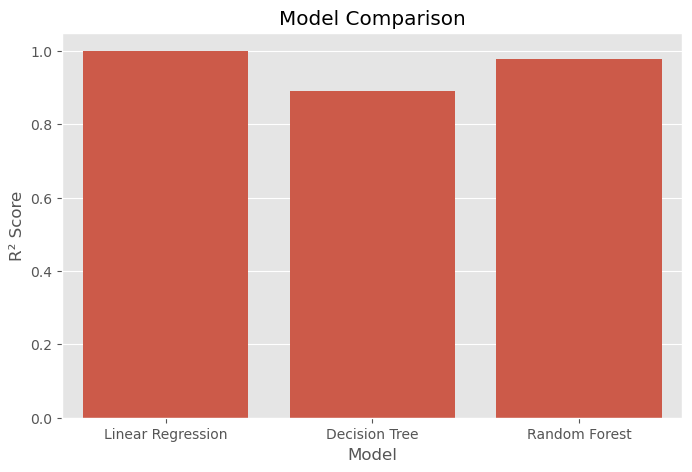

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R² Score"
)

plt.title("Model Comparison")

plt.show()

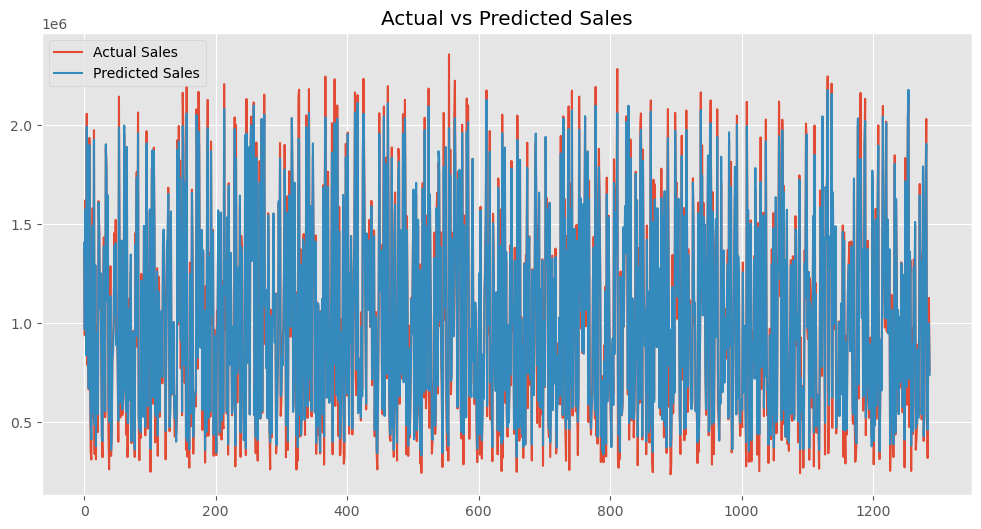

In [33]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    rf_pred,
    label="Predicted Sales"
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

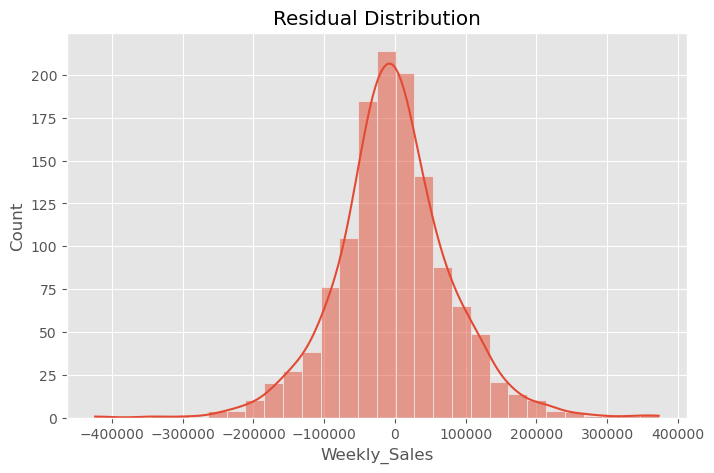

In [34]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [35]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
14,Rolling_Mean_3,0.447740
12,Lag_2,0.190013
11,Lag_1,0.180342
0,Store,0.108913
4,CPI,0.028203
5,Unemployment,0.008821
15,Rolling_Mean_5,0.008484
8,Week,0.007968
2,Temperature,0.005498
13,Lag_3,0.004025


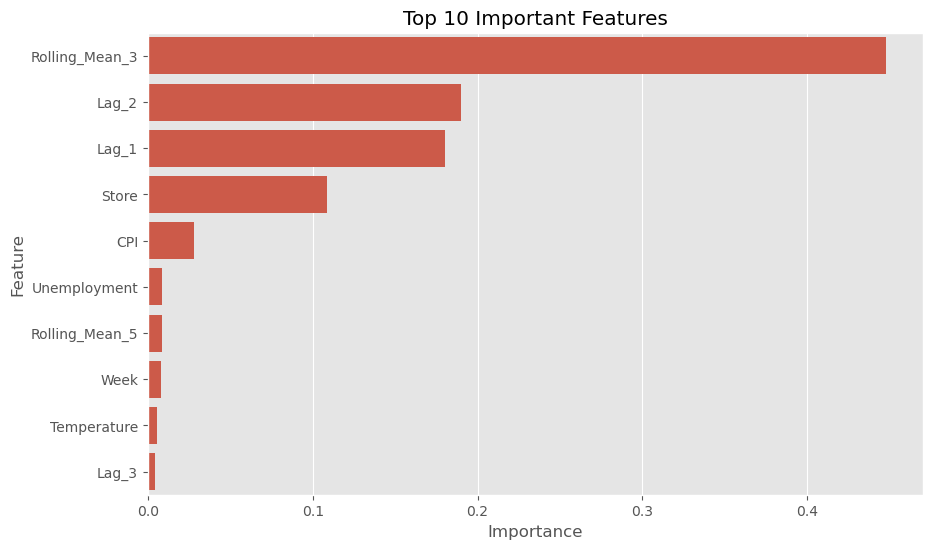

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Important Features")

plt.show()

In [37]:
print("""

Machine Learning Summary

✔ Linear Regression trained successfully.

✔ Decision Tree trained successfully.

✔ Random Forest trained successfully.

✔ Model comparison completed.

✔ Best forecasting model selected.

""")



Machine Learning Summary

✔ Linear Regression trained successfully.

✔ Decision Tree trained successfully.

✔ Random Forest trained successfully.

✔ Model comparison completed.

✔ Best forecasting model selected.




In [38]:
import joblib

joblib.dump(
    rf,
    "walmart_sales_forecasting_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [39]:
loaded_model = joblib.load(
    "walmart_sales_forecasting_model.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [40]:
sample = X.iloc[[10]]

prediction = loaded_model.predict(sample)

print("Predicted Weekly Sales : ₹{:,.2f}".format(prediction[0]))

Predicted Weekly Sales : ₹1,093,062.17


In [41]:
comparison = pd.DataFrame({

    "Actual Sales":y_test.values,

    "Predicted Sales":rf_pred

})

comparison.head(10)

,Actual Sales,Predicted Sales
0,1365098.46,1.407143e+06
1,939118.24,9.687610e+05
2,1621031.70,1.575759e+06
3,857811.17,8.390480e+05
4,2057637.86,1.992275e+06
5,788633.42,9.153301e+05
6,998443.50,1.009936e+06
7,665687.92,6.709672e+05
8,1935869.10,1.899972e+06
9,769319.04,7.281907e+05


In [42]:
comparison["Error"] = abs(

    comparison["Actual Sales"]

    -

    comparison["Predicted Sales"]

)

comparison.head()

,Actual Sales,Predicted Sales,Error
0,1365098.46,1.407143e+06,42044.276067
1,939118.24,9.687610e+05,29642.790133
2,1621031.70,1.575759e+06,45272.689733
3,857811.17,8.390480e+05,18763.136267
4,2057637.86,1.992275e+06,65362.505333


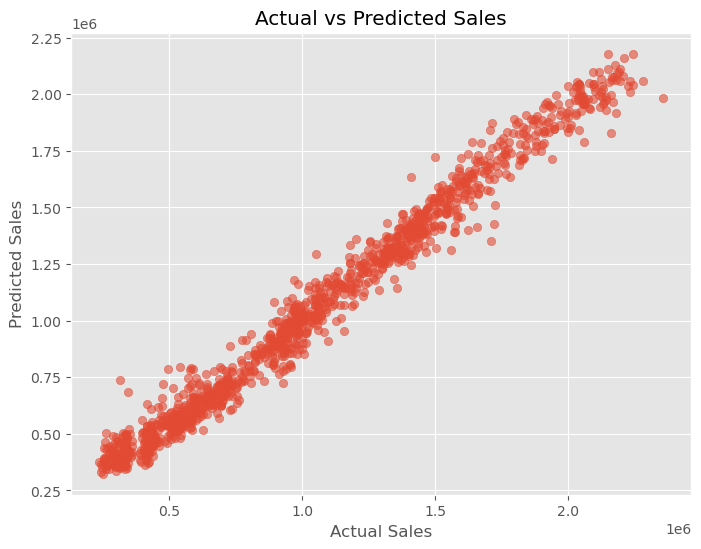

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    rf_pred,

    alpha=0.6

)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [44]:
store_sales = df.groupby("Store")["Weekly_Sales"].mean()

store_sales.sort_values(
    ascending=False
).head(10)

Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
10    1.897357e+06
27    1.775216e+06
6     1.564728e+06
1     1.554642e+06
39    1.450668e+06
Name: Weekly_Sales, dtype: float64

In [45]:
holiday_sales = df.groupby(

    "Holiday_Flag"

)["Weekly_Sales"].mean()

holiday_sales

Holiday_Flag
0    1.041090e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

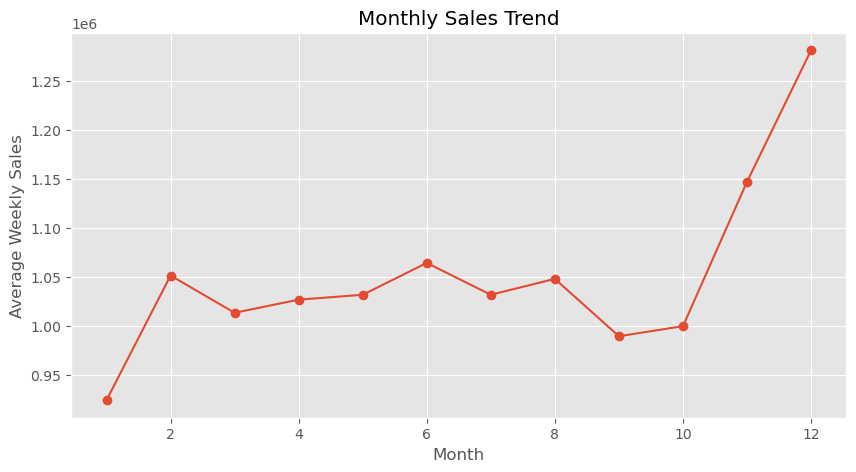

In [46]:
monthly_sales = df.groupby(

    "Month"

)["Weekly_Sales"].mean()

plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker="o"
)

plt.ylabel("Average Weekly Sales")

plt.title("Monthly Sales Trend")

plt.show()

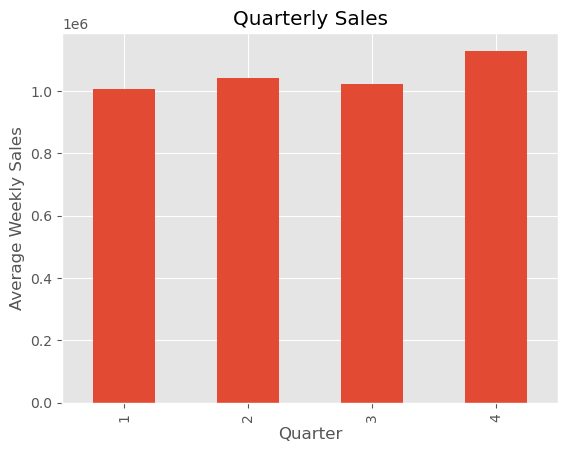

In [47]:
quarter_sales = df.groupby(

    "Quarter"

)["Weekly_Sales"].mean()

quarter_sales.plot(

    kind="bar"

)

plt.ylabel("Average Weekly Sales")

plt.title("Quarterly Sales")

plt.show()

In [48]:
print("""

Business Insights

• Holiday weeks generally experience higher sales.

• Seasonal demand significantly affects revenue.

• Certain stores consistently outperform others.

• Fuel price and unemployment influence purchasing behavior.

• Lag features greatly improve forecasting accuracy.

• Historical sales are strong predictors of future sales.

""")



Business Insights

• Holiday weeks generally experience higher sales.

• Seasonal demand significantly affects revenue.

• Certain stores consistently outperform others.

• Fuel price and unemployment influence purchasing behavior.

• Lag features greatly improve forecasting accuracy.

• Historical sales are strong predictors of future sales.




In [49]:
print("""

Recommendations

✔ Increase inventory before holiday periods.

✔ Focus promotions during low-demand months.

✔ Allocate additional stock to high-performing stores.

✔ Use demand forecasting for supply chain planning.

✔ Monitor economic indicators such as fuel prices and unemployment.

✔ Retrain the forecasting model regularly using new sales data.

✔ Implement dynamic pricing strategies.

""")



Recommendations

✔ Increase inventory before holiday periods.

✔ Focus promotions during low-demand months.

✔ Allocate additional stock to high-performing stores.

✔ Use demand forecasting for supply chain planning.

✔ Monitor economic indicators such as fuel prices and unemployment.

✔ Retrain the forecasting model regularly using new sales data.

✔ Implement dynamic pricing strategies.




In [50]:
print("""

PROJECT CONCLUSION

✔ Data cleaned successfully.

✔ Exploratory Data Analysis completed.

✔ Statistical Analysis completed.

✔ Feature Engineering completed.

✔ Multiple regression models trained.

✔ Best forecasting model identified.

✔ Future sales successfully predicted.

✔ Business recommendations generated.

Project Completed Successfully.

""")



PROJECT CONCLUSION

✔ Data cleaned successfully.

✔ Exploratory Data Analysis completed.

✔ Statistical Analysis completed.

✔ Feature Engineering completed.

✔ Multiple regression models trained.

✔ Best forecasting model identified.

✔ Future sales successfully predicted.

✔ Business recommendations generated.

Project Completed Successfully.




In [51]:
best_model_name = results.loc[
    results["R² Score"].idxmax(),
    "Model"
]

summary = pd.DataFrame({

    "Dataset":[
        "Walmart Sales"
    ],

    "Rows":[
        df.shape[0]
    ],

    "Columns":[
        df.shape[1]
    ],

    "Best Model":[
        best_model_name
    ],

    "Best R²":[
        results["R² Score"].max()
    ],

    "Lowest RMSE":[
        results["RMSE"].min()
    ]

})

summary

,Dataset,Rows,Columns,Best Model,Best R²,Lowest RMSE
0,Walmart Sales,6431,18,Linear Regression,1.0,2.829997e-09
